# Risk Calculation System — Analysis Notebook

This notebook demonstrates the full risk calculation workflow end-to-end and provides visual analysis of:

- Portfolio composition and historical price dynamics
- Calibrated return statistics (mean, volatility, correlation)
- Loss distributions from historical and Monte Carlo simulation
- VaR and ES results across all three methods
- Rolling backtest results with exception analysis
- Verification that exceptions are not clustering in time


In [1]:
import sys
from pathlib import Path

# Make sure the project root is on the path when running from notebooks/
PROJECT_ROOT = Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from src.backtesting import backtest_var, summarize_backtest
from src.calibration import calibrate_from_history, compute_log_returns
from src.input_loader import load_portfolio
from src.market_data import load_price_history
from src.portfolio import portfolio_delta_exposures, value_portfolio
from src.risk_models import historical_var_es, monte_carlo_var_es, parametric_var

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Imports OK. Project root:", PROJECT_ROOT)

Imports OK. Project root: /Users/elisatofanelli/Downloads/risk-main


## 1. Load Portfolio and Market Data

In [2]:
PORTFOLIO_PATH = PROJECT_ROOT / "data" / "sample_portfolio.csv"
HISTORY_PATH   = PROJECT_ROOT / "data" / "sample_historical_prices.csv"
VALUATION_DATE = datetime(2026, 5, 11)

portfolio_df   = load_portfolio(str(PORTFOLIO_PATH))
price_history  = load_price_history(str(HISTORY_PATH))
spot_prices    = price_history.iloc[-1].to_dict()
calib          = calibrate_from_history(price_history)

print(f"Portfolio instruments : {len(portfolio_df)}")
print(f"Price history rows    : {len(price_history)}")
print(f"Date range            : {price_history.index[0].date()} → {price_history.index[-1].date()}")
print(f"Spot prices           : { {k: round(v,2) for k,v in spot_prices.items()} }")
print()
print("Portfolio:")
display(portfolio_df[[
    "instrument_id", "type", "underlying", "position",
    "strike", "maturity", "option_type", "implied_vol", "risk_free_rate"
]].fillna("-"))

Portfolio instruments : 4
Price history rows    : 320
Date range            : 2025-01-02 → 2026-03-25
Spot prices           : {'AAPL': 375.36, 'MSFT': 355.69, 'SPY': 405.43}

Portfolio:


,instrument_id,type,underlying,position,strike,maturity,option_type,implied_vol,risk_free_rate
0,STK1,stock,AAPL,100,-,-,-,-,-
1,STK2,stock,MSFT,-50,-,-,-,-,-
2,OPT1,option,AAPL,20,200.0,2027-06-30 00:00:00,call,0.25,0.04
3,OPT2,option,MSFT,-15,350.0,2027-06-30 00:00:00,put,0.3,0.04


## 2. Historical Price Dynamics

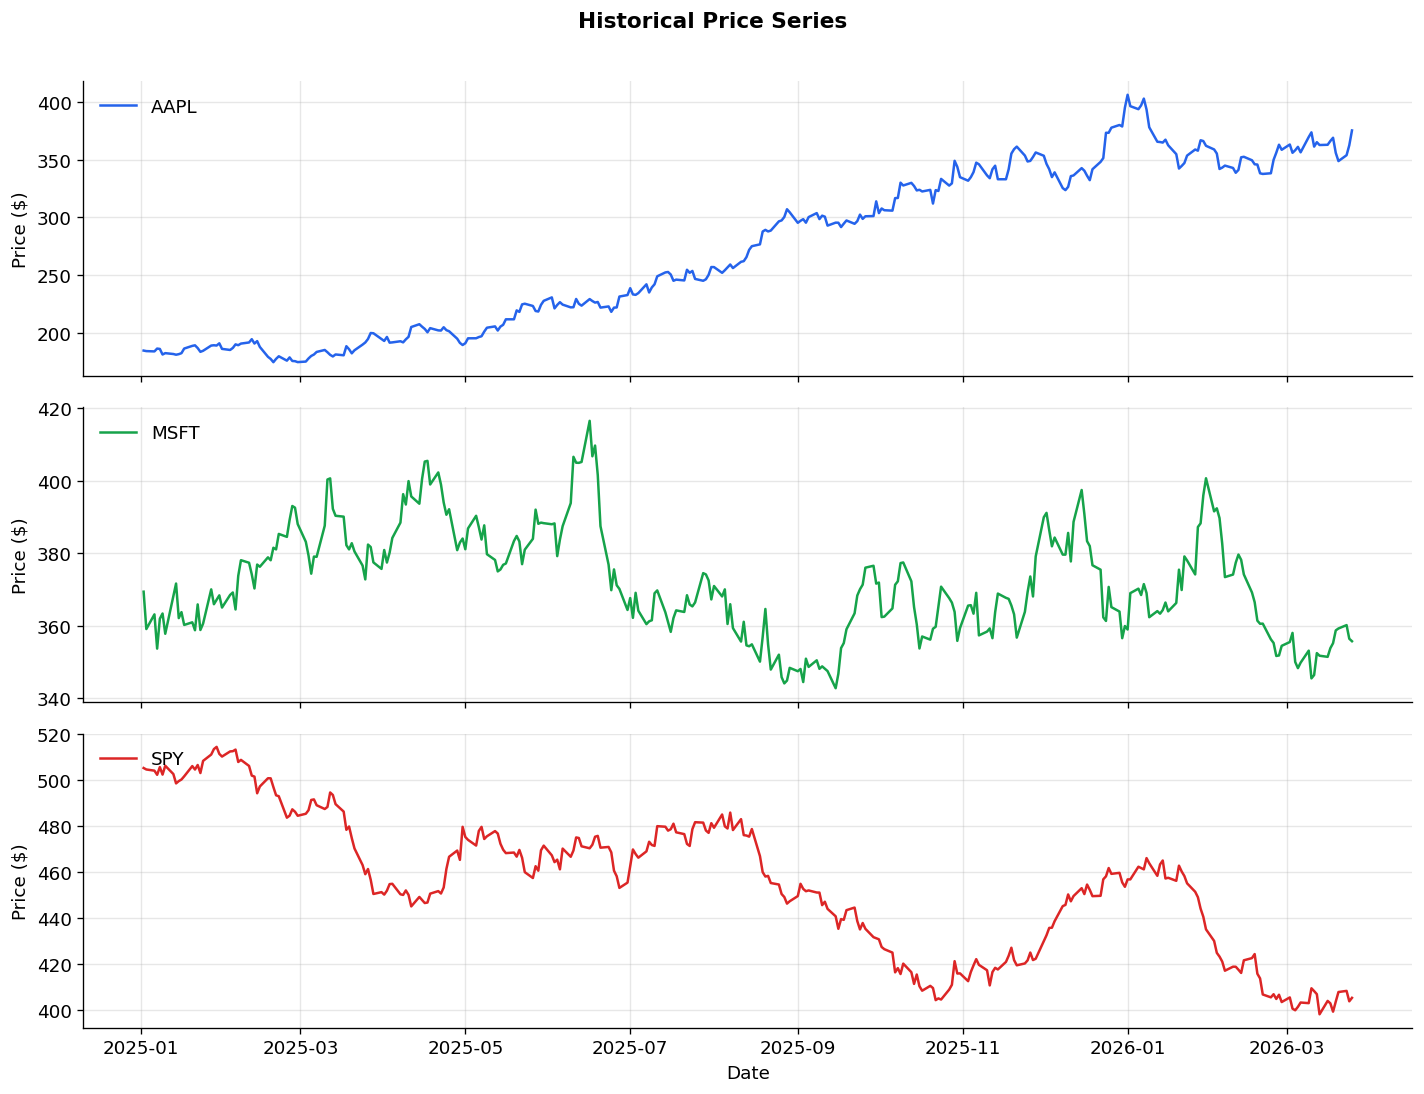

In [3]:
tickers = list(price_history.columns)
colors  = ["#2563EB", "#16A34A", "#DC2626"]

fig, axes = plt.subplots(len(tickers), 1, figsize=(12, 3 * len(tickers)), sharex=True)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker, color in zip(axes, tickers, colors):
    ax.plot(price_history.index, price_history[ticker], color=color, linewidth=1.5, label=ticker)
    ax.set_ylabel("Price ($)")
    ax.legend(loc="upper left", frameon=False)

axes[-1].set_xlabel("Date")
fig.suptitle("Historical Price Series", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3. Calibrated Return Statistics

Log returns are used throughout the system. The sample mean and covariance estimated here feed into the parametric and Monte Carlo VaR models.

In [4]:
log_returns = compute_log_returns(price_history)

print("Daily log-return statistics:")
stats = pd.DataFrame({
    "Mean (daily)":       calib["daily_mean_returns"],
    "Std Dev (daily)":    calib["daily_volatility"],
    "Ann. Mean":          calib["annualized_mean_returns"],
    "Ann. Volatility":    calib["annualized_volatility"],
}).round(6)
display(stats)

print("\nCorrelation matrix:")
display(calib["correlation_matrix"].round(4))

Daily log-return statistics:


,Mean (daily),Std Dev (daily),Ann. Mean,Ann. Volatility
AAPL,0.002224,0.018154,0.560508,0.288181
MSFT,-0.000118,0.013583,-0.029813,0.215626
SPY,-0.000690,0.008467,-0.173814,0.134413



Correlation matrix:


,AAPL,MSFT,SPY
AAPL,1.0000,-0.0375,-0.0720
MSFT,-0.0375,1.0000,0.0435
SPY,-0.0720,0.0435,1.0000


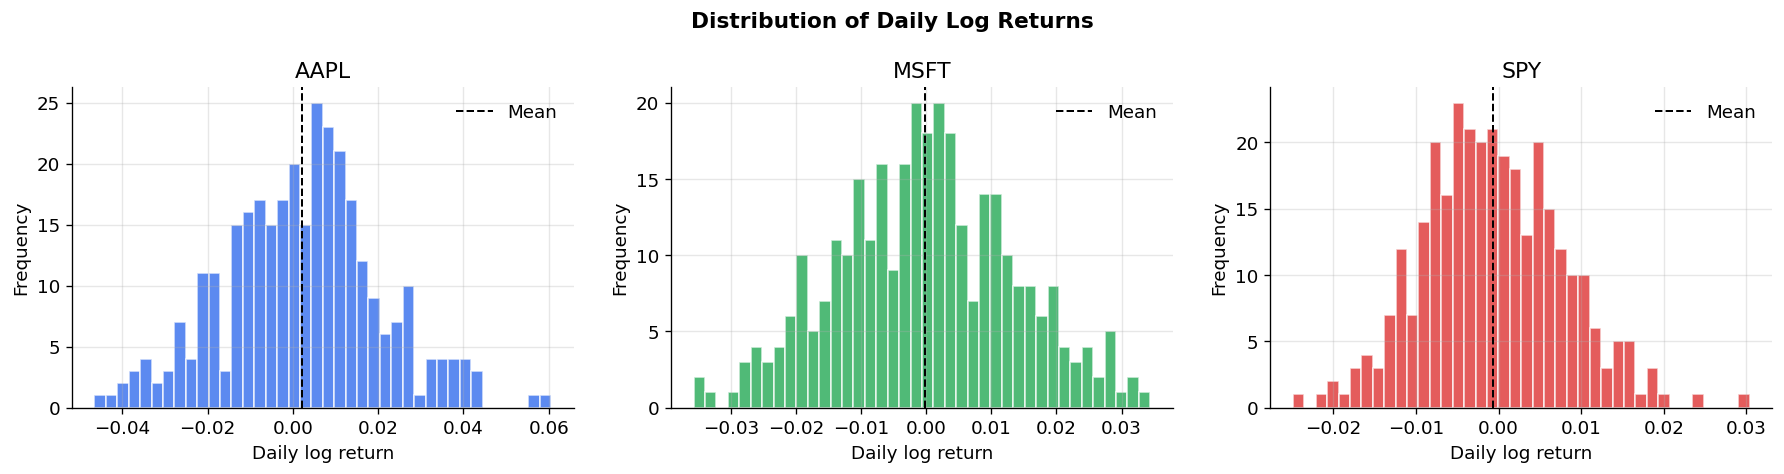

In [5]:
fig, axes = plt.subplots(1, len(tickers), figsize=(5 * len(tickers), 4), sharey=False)
if len(tickers) == 1:
    axes = [axes]

for ax, ticker, color in zip(axes, tickers, colors):
    returns_series = log_returns[ticker].dropna()
    ax.hist(returns_series, bins=40, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(returns_series.mean(), color="black", linestyle="--", linewidth=1.2, label="Mean")
    ax.set_title(ticker)
    ax.set_xlabel("Daily log return")
    ax.set_ylabel("Frequency")
    ax.legend(frameon=False)

fig.suptitle("Distribution of Daily Log Returns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

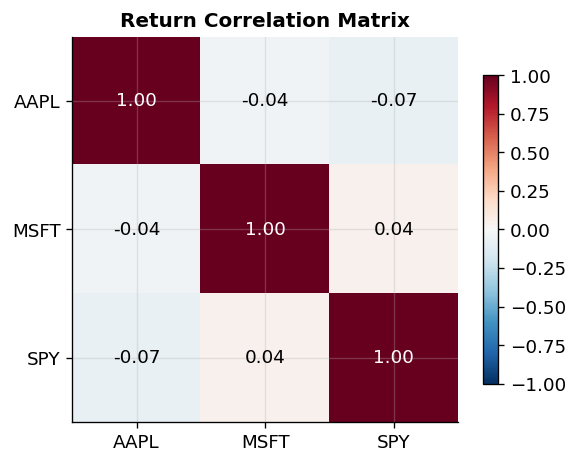

In [6]:
# Correlation heatmap
corr = calib["correlation_matrix"]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers)
ax.set_yticklabels(tickers)
plt.colorbar(im, ax=ax, shrink=0.8)
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center",
                fontsize=11, color="white" if abs(corr.values[i,j]) > 0.5 else "black")
ax.set_title("Return Correlation Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Portfolio Valuation and Delta Exposures

In [7]:
portfolio_value = value_portfolio(portfolio_df, spot_prices, VALUATION_DATE)
deltas = portfolio_delta_exposures(portfolio_df, spot_prices, VALUATION_DATE)

print(f"Portfolio value on {VALUATION_DATE.date()}: ${portfolio_value:,.2f}")
print()
print("Delta exposures (position × delta × spot):")
for underlying, delta in deltas.items():
    dollar_exposure = delta * spot_prices[underlying]
    print(f"  {underlying:6s}  delta={delta:+.4f}   dollar exposure=${dollar_exposure:+,.2f}")

Portfolio value on 2026-05-11: $22,928.71

Delta exposures (position × delta × spot):
  AAPL    delta=+119.9231   dollar exposure=$+45,014.35
  MSFT    delta=-44.5667   dollar exposure=$-15,851.93


## 5. VaR and ES — All Three Methods

- **Historical**: full revaluation under observed log-return scenarios
- **Monte Carlo**: full revaluation under 10,000 simulated correlated log-return scenarios
- **Parametric**: delta-normal closed-form approximation

In [8]:
CONFIDENCE = 0.95
N_SIMS     = 10_000

hist_result  = historical_var_es(portfolio_df, price_history, VALUATION_DATE, confidence_level=CONFIDENCE)
mc_result    = monte_carlo_var_es(portfolio_df, spot_prices, calib, VALUATION_DATE,
                                  confidence_level=CONFIDENCE, n_sims=N_SIMS, random_seed=42)
param_result = parametric_var(portfolio_df, spot_prices, calib, VALUATION_DATE,
                              confidence_level=CONFIDENCE)

summary = pd.DataFrame([
    {"Method": "Historical",   "VaR": hist_result["VaR"],  "ES": hist_result["ES"],
     "Scenarios": hist_result["number_of_scenarios"]},
    {"Method": "Monte Carlo",  "VaR": mc_result["VaR"],    "ES": mc_result["ES"],
     "Scenarios": mc_result["number_of_scenarios"]},
    {"Method": "Parametric",   "VaR": param_result["VaR"], "ES": param_result["ES"],
     "Scenarios": "N/A (closed form)"},
])

print(f"Confidence level: {CONFIDENCE:.0%}   |   Portfolio value: ${portfolio_value:,.2f}")
print()
display(summary.set_index("Method").style.format(
    {"VaR": "${:,.2f}", "ES": "${:,.2f}"}, na_rep="N/A"
))

Confidence level: 95%   |   Portfolio value: $22,928.71



,VaR,ES,Scenarios
Method,,,
Historical,"$1,300.05","$1,629.30",319
Monte Carlo,"$1,300.31","$1,671.18",10000
Parametric,"$1,300.80","$1,657.17",N/A (closed form)


## 6. Loss Distributions — Historical and Monte Carlo

The plots below show the full empirical loss distributions. The vertical lines mark VaR and ES. The tail beyond VaR is shaded — ES is the average loss in that shaded region.

In [9]:
def compute_losses(portfolio_df, price_history, spot_prices, valuation_date):
    """Recompute historical scenario losses for plotting."""
    from src.calibration import compute_log_returns
    log_returns = compute_log_returns(price_history).dropna(how="any")
    current_value = value_portfolio(portfolio_df, spot_prices, valuation_date)
    losses = []
    for _, r in log_returns.iterrows():
        scenario_prices = {col: float(spot_prices[col] * np.exp(r[col]))
                           for col in price_history.columns if col in spot_prices}
        scenario_value = value_portfolio(portfolio_df, scenario_prices, valuation_date)
        losses.append(-(scenario_value - current_value))
    return np.array(losses)

def compute_mc_losses(portfolio_df, spot_prices, calib, valuation_date, n_sims=10000, seed=42):
    """Recompute Monte Carlo scenario losses for plotting."""
    cols = list(spot_prices.keys())
    mu  = calib["daily_mean_returns"].reindex(cols).fillna(0).values
    cov = calib["daily_cov_matrix"].reindex(index=cols, columns=cols).fillna(0).values
    rng = np.random.default_rng(seed)
    sims = rng.multivariate_normal(mu, cov, size=n_sims)
    current_value = value_portfolio(portfolio_df, spot_prices, valuation_date)
    losses = []
    for scenario in sims:
        sp = {col: float(spot_prices[col] * np.exp(scenario[i])) for i, col in enumerate(cols)}
        losses.append(-(value_portfolio(portfolio_df, sp, valuation_date) - current_value))
    return np.array(losses)

hist_losses = compute_losses(portfolio_df, price_history, spot_prices, VALUATION_DATE)
mc_losses   = compute_mc_losses(portfolio_df, spot_prices, calib, VALUATION_DATE, n_sims=N_SIMS)

print(f"Historical scenarios : {len(hist_losses)}")
print(f"Monte Carlo scenarios: {len(mc_losses)}")

Historical scenarios : 319
Monte Carlo scenarios: 10000


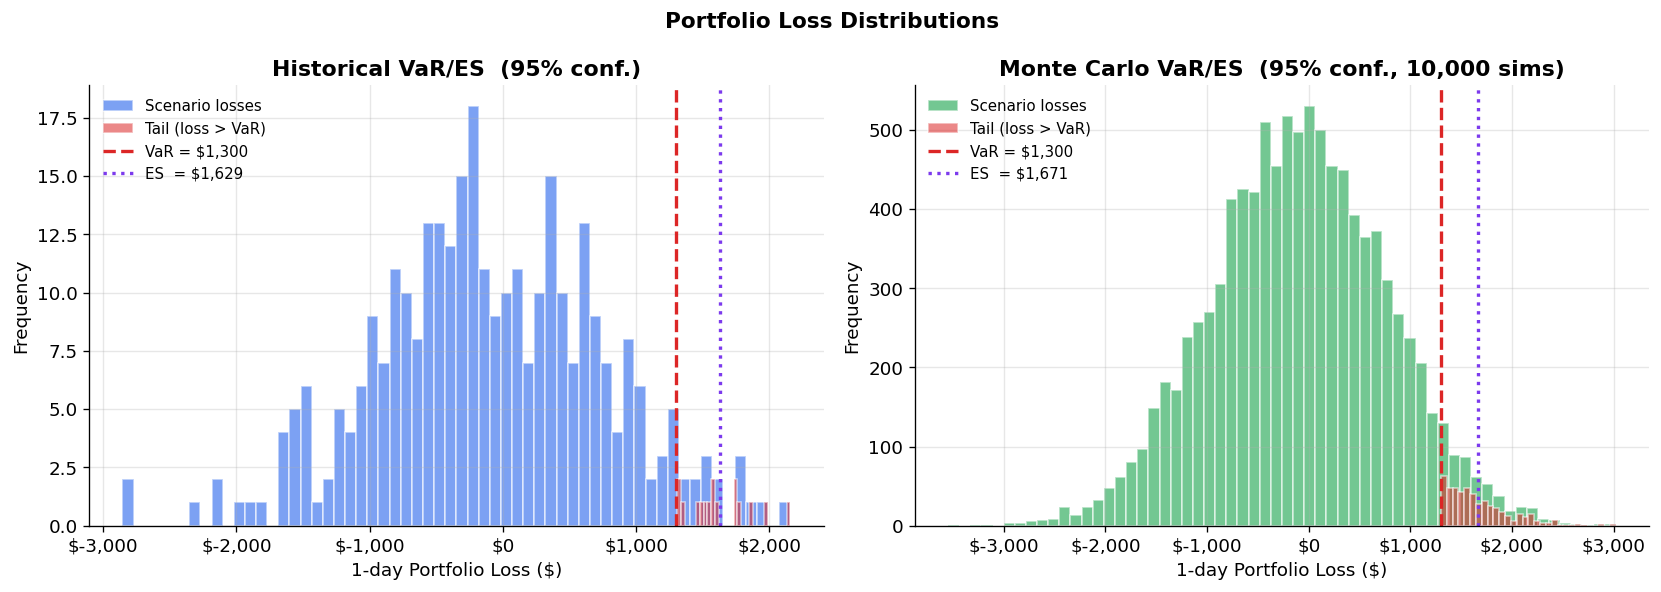

In [10]:
def plot_loss_distribution(losses, var, es, title, color, ax):
    ax.hist(losses, bins=60, color=color, alpha=0.6, edgecolor="white", label="Scenario losses")
    # Shade the tail beyond VaR
    tail_losses = losses[losses >= var]
    if len(tail_losses):
        ax.hist(tail_losses, bins=30, color="#DC2626", alpha=0.55, edgecolor="white", label="Tail (loss > VaR)")
    ax.axvline(var, color="#DC2626", linewidth=2, linestyle="--", label=f"VaR = ${var:,.0f}")
    if es is not None:
        ax.axvline(es, color="#7C3AED", linewidth=2, linestyle=":", label=f"ES  = ${es:,.0f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("1-day Portfolio Loss ($)")
    ax.set_ylabel("Frequency")
    ax.legend(frameon=False, fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_loss_distribution(
    hist_losses, hist_result["VaR"], hist_result["ES"],
    f"Historical VaR/ES  (95% conf.)", "#2563EB", axes[0]
)
plot_loss_distribution(
    mc_losses, mc_result["VaR"], mc_result["ES"],
    f"Monte Carlo VaR/ES  (95% conf., {N_SIMS:,} sims)", "#16A34A", axes[1]
)

fig.suptitle("Portfolio Loss Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. VaR Sensitivity to Confidence Level

Lecture 5 recommends testing a variety of percentiles. The plot below shows how VaR and ES vary across confidence levels for all three methods.

In [11]:
confidence_levels = [0.90, 0.925, 0.95, 0.975, 0.99]

rows = []
for cl in confidence_levels:
    h = historical_var_es(portfolio_df, price_history, VALUATION_DATE, confidence_level=cl)
    m = monte_carlo_var_es(portfolio_df, spot_prices, calib, VALUATION_DATE,
                           confidence_level=cl, n_sims=N_SIMS, random_seed=42)
    p = parametric_var(portfolio_df, spot_prices, calib, VALUATION_DATE, confidence_level=cl)
    rows.append({
        "confidence_level": cl,
        "hist_VaR":   h["VaR"],  "hist_ES":  h["ES"],
        "mc_VaR":     m["VaR"],  "mc_ES":    m["ES"],
        "param_VaR":  p["VaR"],  "param_ES": p["ES"],
    })

sensitivity_df = pd.DataFrame(rows).set_index("confidence_level")
display(sensitivity_df.style.format("${:,.2f}"))

,hist_VaR,hist_ES,mc_VaR,mc_ES,param_VaR,param_ES
confidence_level,,,,,,
0.900000,$948.91,"$1,377.26","$1,001.71","$1,403.40",$990.96,"$1,394.72"
0.925000,"$1,131.71","$1,496.62","$1,127.29","$1,517.59","$1,125.69","$1,507.66"
0.950000,"$1,300.05","$1,629.30","$1,300.31","$1,671.18","$1,300.80","$1,657.17"
0.975000,"$1,566.60","$1,812.43","$1,588.07","$1,906.84","$1,569.54","$1,891.78"
0.990000,"$1,776.48","$1,947.29","$1,886.63","$2,181.89","$1,882.01","$2,171.01"


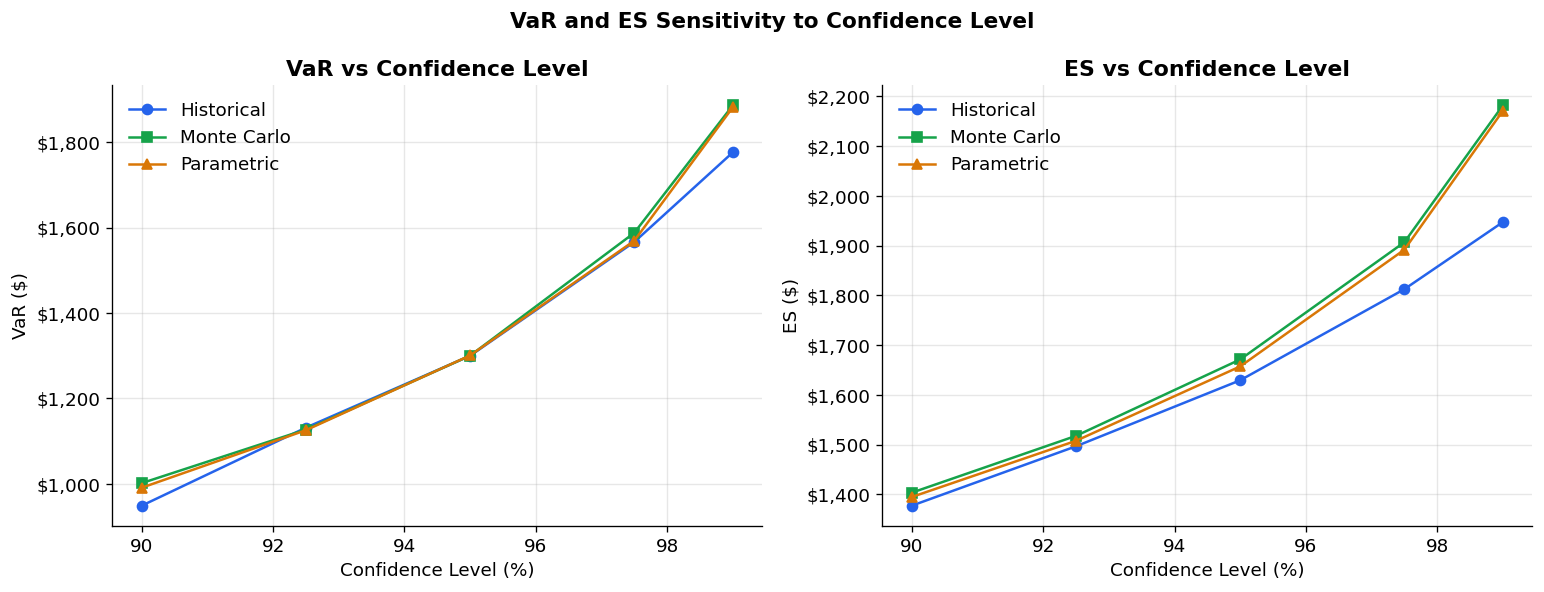

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cl_pct = [c * 100 for c in confidence_levels]

axes[0].plot(cl_pct, sensitivity_df["hist_VaR"],  "o-", color="#2563EB", label="Historical")
axes[0].plot(cl_pct, sensitivity_df["mc_VaR"],    "s-", color="#16A34A", label="Monte Carlo")
axes[0].plot(cl_pct, sensitivity_df["param_VaR"], "^-", color="#D97706", label="Parametric")
axes[0].set_title("VaR vs Confidence Level", fontweight="bold")
axes[0].set_xlabel("Confidence Level (%)")
axes[0].set_ylabel("VaR ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend(frameon=False)

axes[1].plot(cl_pct, sensitivity_df["hist_ES"],  "o-", color="#2563EB", label="Historical")
axes[1].plot(cl_pct, sensitivity_df["mc_ES"],    "s-", color="#16A34A", label="Monte Carlo")
axes[1].plot(cl_pct, sensitivity_df["param_ES"], "^-", color="#D97706", label="Parametric")
axes[1].set_title("ES vs Confidence Level", fontweight="bold")
axes[1].set_xlabel("Confidence Level (%)")
axes[1].set_ylabel("ES ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].legend(frameon=False)

fig.suptitle("VaR and ES Sensitivity to Confidence Level", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Rolling Backtest — Actual Loss vs. VaR Over Time

The backtest runs rolling one-day-ahead VaR forecasts. For each day, the actual portfolio loss is compared to the forecasted VaR. Days where the actual loss exceeds VaR are **exceptions** (shown in red).

In [13]:
print("Running rolling backtests")
bt_hist  = backtest_var(portfolio_df, price_history, "historical",  confidence_level=0.95)
bt_param = backtest_var(portfolio_df, price_history, "parametric",  confidence_level=0.95)
bt_mc    = backtest_var(portfolio_df, price_history, "monte_carlo", confidence_level=0.95, n_sims=2000)

for bt in [bt_hist, bt_param, bt_mc]:
    bt["date"] = pd.to_datetime(bt["date"])

summaries = [summarize_backtest(bt_hist), summarize_backtest(bt_param), summarize_backtest(bt_mc)]
summary_df = pd.DataFrame(summaries).set_index("method")
display(summary_df[[
    "number_of_observations", "number_of_exceptions",
    "expected_exception_rate", "actual_exception_rate",
    "pass_fail_simple", "kupiec_p_value",
    "consecutive_exception_pairs", "clustering_concern"
]].round(4))

Running rolling backtests


,number_of_observations,number_of_exceptions,expected_exception_rate,actual_exception_rate,pass_fail_simple,kupiec_p_value,consecutive_exception_pairs,clustering_concern
method,,,,,,,,
historical,69,7,0.05,0.1014,False,0.0832,1,False
parametric,69,7,0.05,0.1014,False,0.0832,1,False
monte_carlo,69,7,0.05,0.1014,False,0.0832,1,False


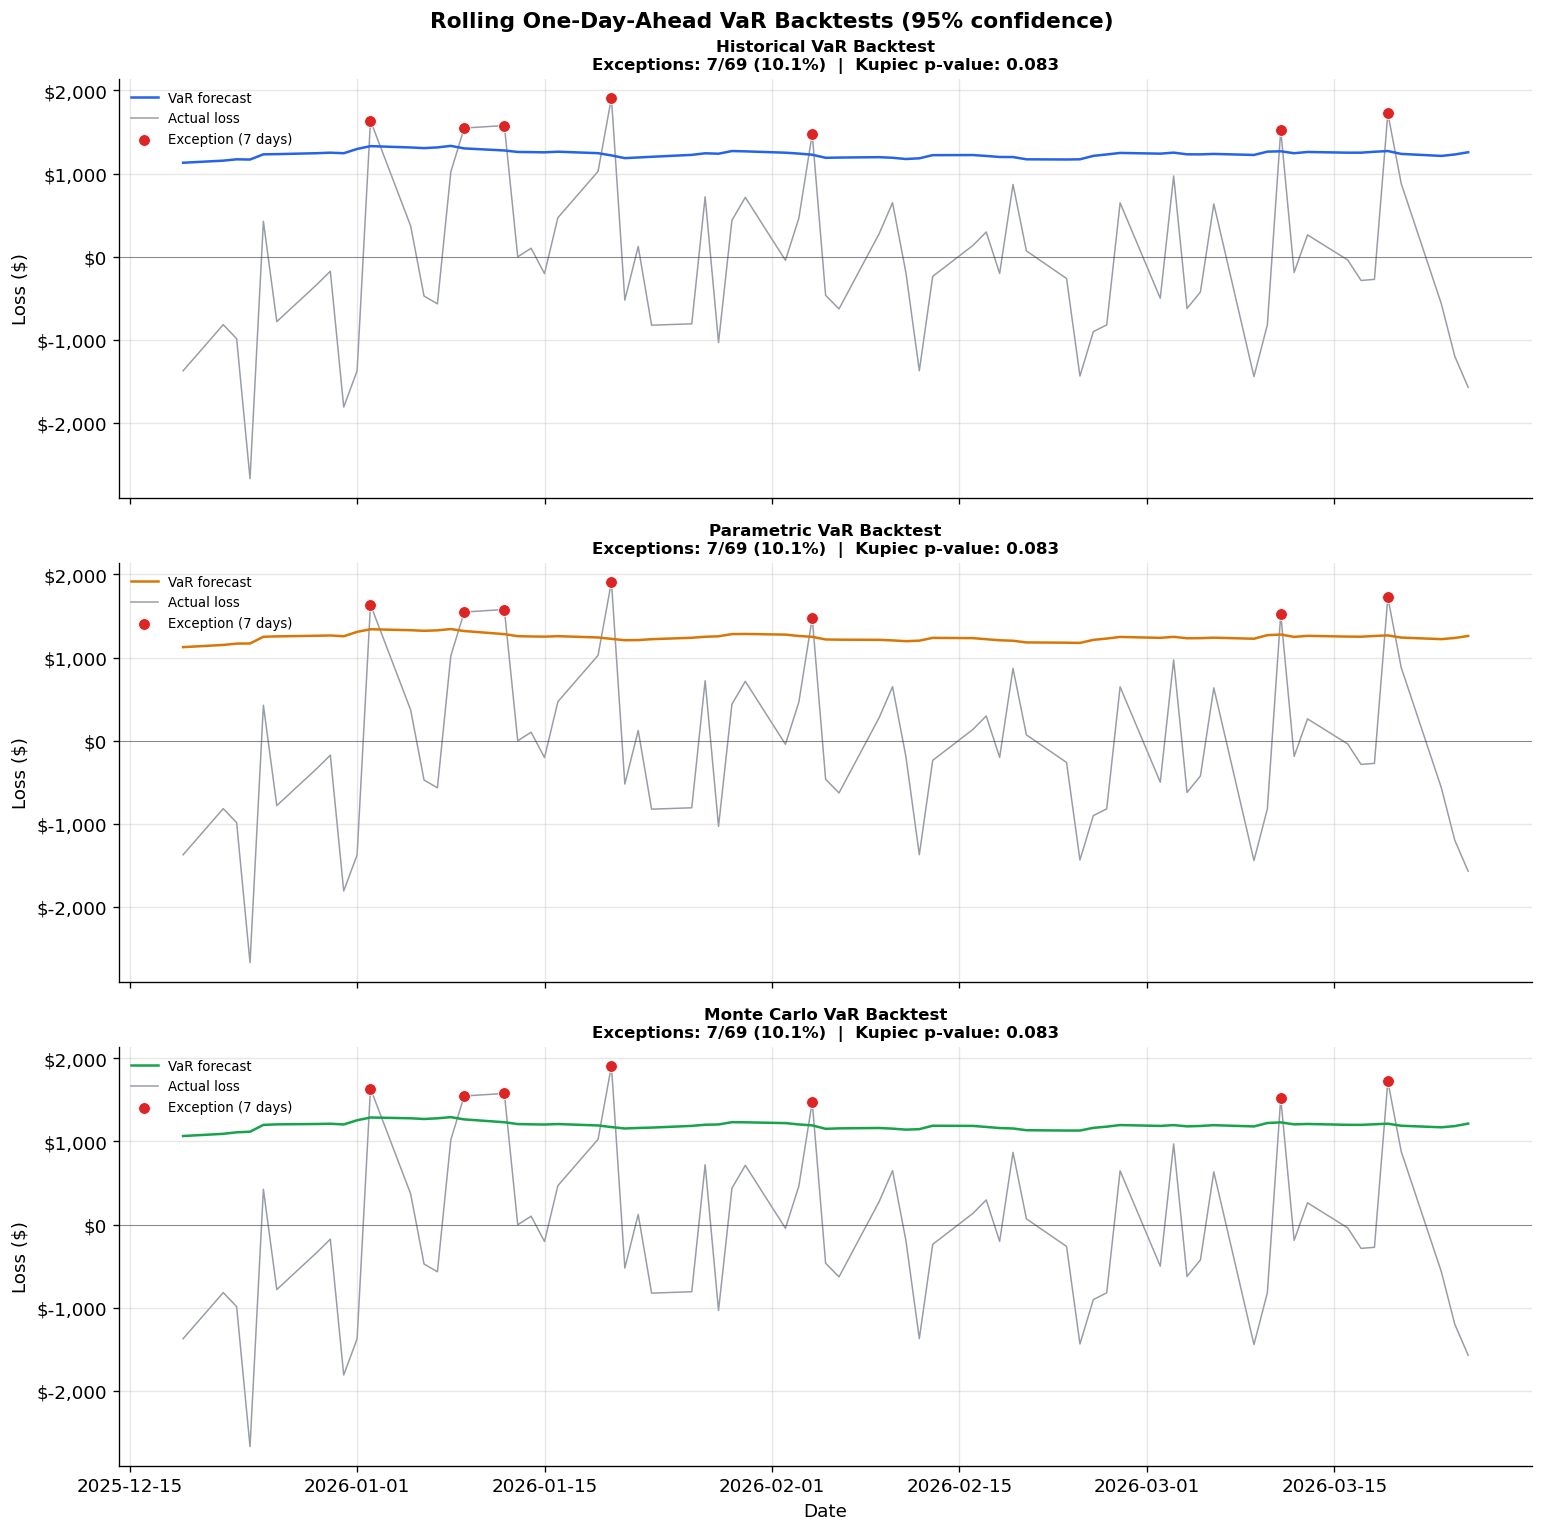

In [14]:
def plot_backtest(bt_df, summary, ax, color, title):
    dates      = bt_df["date"]
    act_loss   = bt_df["actual_loss"]
    var_series = bt_df["VaR"]
    exceptions = bt_df["exception"]

    ax.plot(dates, var_series, color=color, linewidth=1.5, label="VaR forecast", zorder=2)
    ax.plot(dates, act_loss,   color="#6B7280", linewidth=0.9, alpha=0.7, label="Actual loss", zorder=1)

    exc_dates  = dates[exceptions]
    exc_losses = act_loss[exceptions]
    ax.scatter(exc_dates, exc_losses, color="#DC2626", zorder=5, s=50,
               label=f"Exception ({len(exc_dates)} days)", edgecolors="white", linewidth=0.5)

    ax.axhline(0, color="black", linewidth=0.6, linestyle="-", alpha=0.4)
    n   = summary["number_of_observations"]
    exc = summary["number_of_exceptions"]
    rate = summary["actual_exception_rate"]
    pval = summary.get("kupiec_p_value")
    pval_str = f"{pval:.3f}" if pval is not None else "N/A"
    ax.set_title(
        f"{title}\n"
        f"Exceptions: {exc}/{n} ({rate:.1%})  |  Kupiec p-value: {pval_str}",
        fontsize=10, fontweight="bold"
    )
    ax.set_ylabel("Loss ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.legend(frameon=False, fontsize=8, loc="upper left")

fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=True)

plot_backtest(bt_hist,  summaries[0], axes[0], "#2563EB", "Historical VaR Backtest")
plot_backtest(bt_param, summaries[1], axes[1], "#D97706", "Parametric VaR Backtest")
plot_backtest(bt_mc,    summaries[2], axes[2], "#16A34A", "Monte Carlo VaR Backtest")

axes[-1].set_xlabel("Date")
fig.suptitle("Rolling One-Day-Ahead VaR Backtests (95% confidence)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Exception Clustering Analysis

Lecture 5 (slide 37) requires confirming that exceptions are not clustering in time. The plot below shows the timeline of exceptions as a binary event series. Consecutive exceptions on adjacent days would appear as adjacent bars.

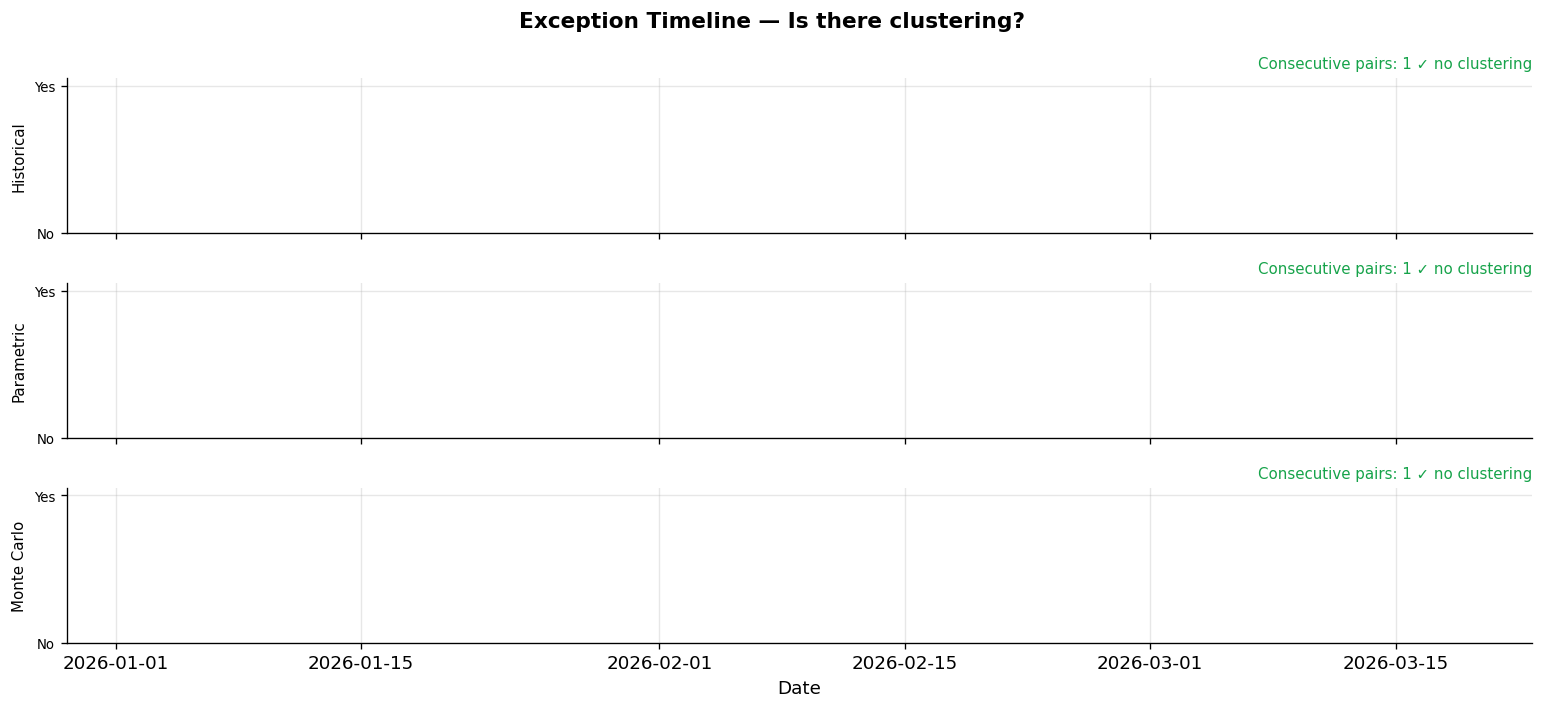

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True)

backtest_pairs = [
    (bt_hist,  summaries[0], "#2563EB", "Historical"),
    (bt_param, summaries[1], "#D97706", "Parametric"),
    (bt_mc,    summaries[2], "#16A34A", "Monte Carlo"),
]

for ax, (bt_df, summary, color, label) in zip(axes, backtest_pairs):
    exc_int = bt_df["exception"].astype(int).values
    dates   = bt_df["date"].values

    ax.bar(dates, exc_int, width=2, color=color, alpha=0.8)
    consecutive = summary.get("consecutive_exception_pairs", 0)
    clustering  = summary.get("clustering_concern", False)
    ax.set_ylabel(label, fontsize=9)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["No", "Yes"], fontsize=8)
    note = f"Consecutive pairs: {consecutive}" + (" ⚠ clustering" if clustering else " ✓ no clustering")
    ax.set_title(note, fontsize=9, loc="right", color="#DC2626" if clustering else "#16A34A")

axes[-1].set_xlabel("Date")
fig.suptitle("Exception Timeline — Is there clustering?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Black-Scholes Behavioral Checks

Lecture 5 (slides 53–54) requires confirming that the model exhibits expected limiting-case behavior. The checks below verify:

- Call price → intrinsic value as volatility → 0
- Call price → spot price as strike → 0  
- Put-call parity holds across a range of strikes
- Option price is monotone in volatility and in spot price

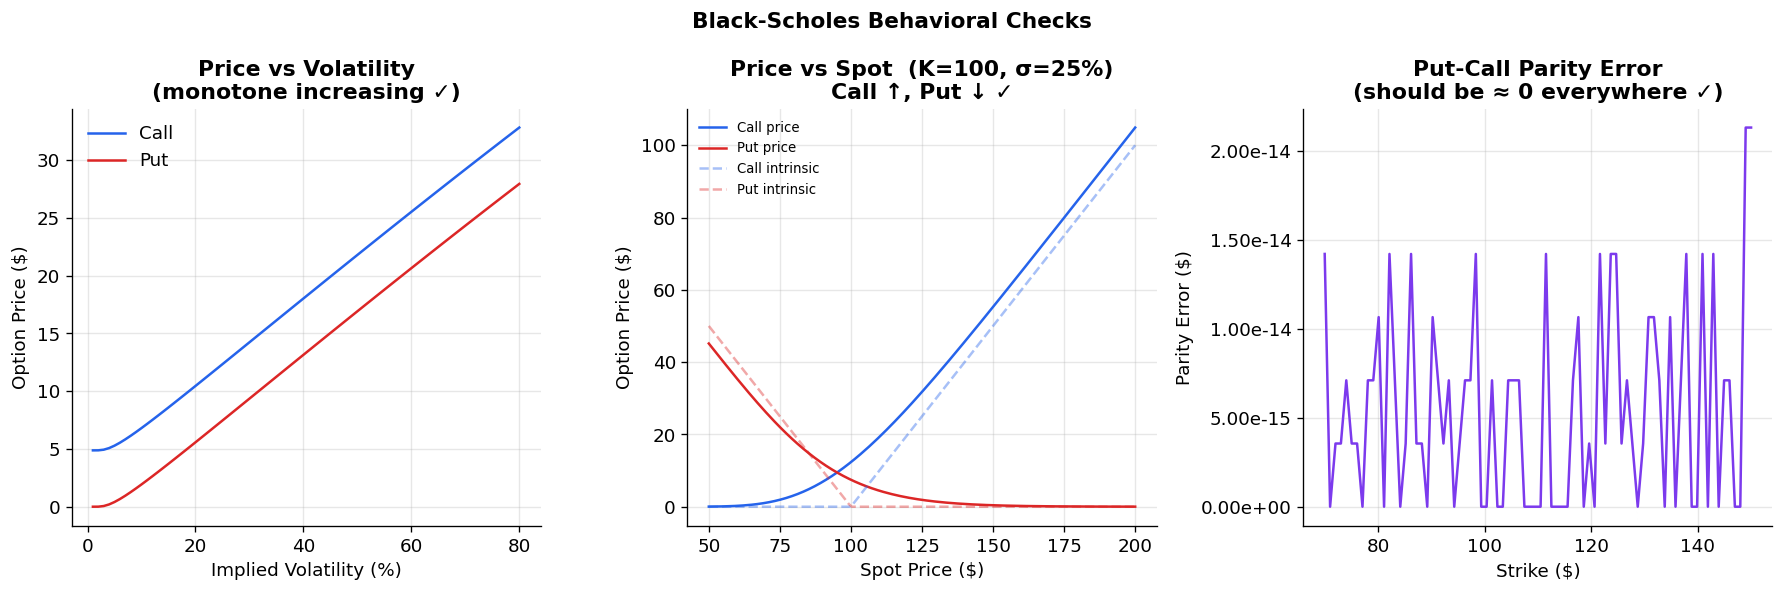

Max put-call parity error across all strikes: 2.13e-14  (should be < 1e-10)
Call price monotone in vol: True
Call price monotone in spot: True
Put price monotone decreasing in spot: True


In [16]:
from math import exp as mexp
from src.pricing import black_scholes_price, black_scholes_delta

S, K, T, r = 100.0, 100.0, 1.0, 0.05

# 1. Price vs volatility (monotone increasing for calls)
vols   = np.linspace(0.01, 0.80, 80)
calls  = [black_scholes_price(S, K, T, v, r, "call") for v in vols]
puts   = [black_scholes_price(S, K, T, v, r, "put")  for v in vols]

# 2. Price vs spot (call is increasing, put is decreasing)
spots  = np.linspace(50, 200, 150)
call_vs_spot = [black_scholes_price(s, K, T, 0.25, r, "call") for s in spots]
put_vs_spot  = [black_scholes_price(s, K, T, 0.25, r, "put")  for s in spots]
intrinsic_call = [max(s - K, 0) for s in spots]
intrinsic_put  = [max(K - s, 0) for s in spots]

# 3. Put-call parity across strikes
strikes = np.linspace(70, 150, 80)
pcp_errors = [
    abs((black_scholes_price(S, k, T, 0.25, r, "call")
         - black_scholes_price(S, k, T, 0.25, r, "put"))
        - (S - k * mexp(-r * T)))
    for k in strikes
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Vol sensitivity
axes[0].plot(vols * 100, calls, color="#2563EB", label="Call")
axes[0].plot(vols * 100, puts,  color="#DC2626", label="Put")
axes[0].set_xlabel("Implied Volatility (%)")
axes[0].set_ylabel("Option Price ($)")
axes[0].set_title("Price vs Volatility\n(monotone increasing ✓)", fontweight="bold")
axes[0].legend(frameon=False)

# Spot sensitivity
axes[1].plot(spots, call_vs_spot,   color="#2563EB",  label="Call price")
axes[1].plot(spots, put_vs_spot,    color="#DC2626",  label="Put price")
axes[1].plot(spots, intrinsic_call, color="#2563EB",  linestyle="--", alpha=0.4, label="Call intrinsic")
axes[1].plot(spots, intrinsic_put,  color="#DC2626",  linestyle="--", alpha=0.4, label="Put intrinsic")
axes[1].set_xlabel("Spot Price ($)")
axes[1].set_ylabel("Option Price ($)")
axes[1].set_title("Price vs Spot  (K=100, σ=25%)\nCall ↑, Put ↓ ✓", fontweight="bold")
axes[1].legend(frameon=False, fontsize=8)

# Put-call parity error
axes[2].plot(strikes, pcp_errors, color="#7C3AED")
axes[2].set_xlabel("Strike ($)")
axes[2].set_ylabel("Parity Error ($)")
axes[2].set_title("Put-Call Parity Error\n(should be ≈ 0 everywhere ✓)", fontweight="bold")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2e}"))

fig.suptitle("Black-Scholes Behavioral Checks", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Max put-call parity error across all strikes: {max(pcp_errors):.2e}  (should be < 1e-10)")
print(f"Call price monotone in vol: {all(calls[i] <= calls[i+1] for i in range(len(calls)-1))}")
print(f"Call price monotone in spot: {all(call_vs_spot[i] <= call_vs_spot[i+1] for i in range(len(call_vs_spot)-1))}")
print(f"Put price monotone decreasing in spot: {all(put_vs_spot[i] >= put_vs_spot[i+1] for i in range(len(put_vs_spot)-1))}")

## 11. Delta Behavior

Delta should be bounded between 0 and 1 for calls and between -1 and 0 for puts, and should approach the boundary values as the option goes deep in- or out-of-the-money.

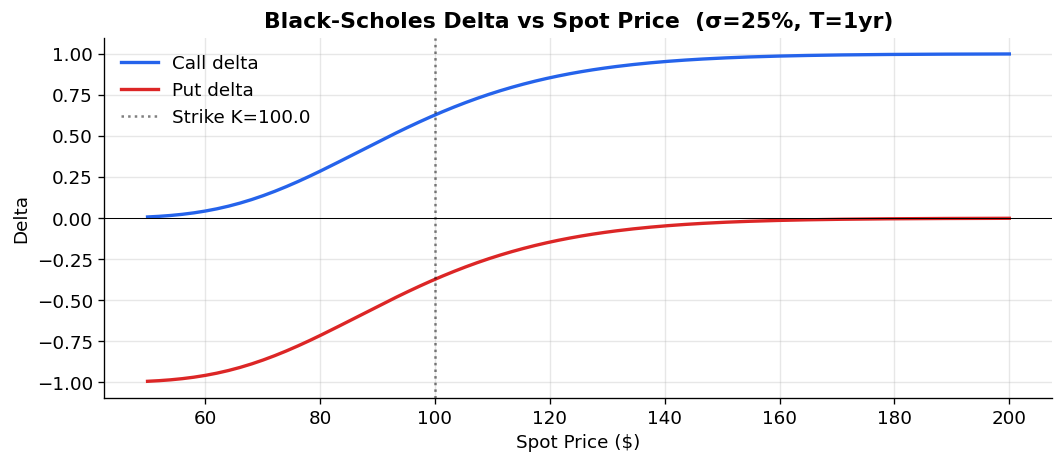

Call delta range: [0.0072, 0.9990]  (expected [0, 1])
Put  delta range: [-0.9928, -0.0010]  (expected [-1, 0])


In [17]:
call_deltas = [black_scholes_delta(s, K, T, 0.25, r, "call") for s in spots]
put_deltas  = [black_scholes_delta(s, K, T, 0.25, r, "put")  for s in spots]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(spots, call_deltas, color="#2563EB", linewidth=2, label="Call delta")
ax.plot(spots, put_deltas,  color="#DC2626", linewidth=2, label="Put delta")
ax.axvline(K, color="black", linestyle=":", alpha=0.5, label=f"Strike K={K}")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_xlabel("Spot Price ($)")
ax.set_ylabel("Delta")
ax.set_title("Black-Scholes Delta vs Spot Price  (σ=25%, T=1yr)", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Call delta range: [{min(call_deltas):.4f}, {max(call_deltas):.4f}]  (expected [0, 1])")
print(f"Put  delta range: [{min(put_deltas):.4f}, {max(put_deltas):.4f}]  (expected [-1, 0])")

## 12. Summary and Interpretation

| Item | Result | Comment |
|---|---|---|
| Portfolio value | ~$22,929 | Dominated by long AAPL stock position |
| Historical VaR (95%) | ~$1,300 | Based on 319 daily scenarios |
| Monte Carlo VaR (95%) | ~$1,300 | 10,000 simulated scenarios |
| Parametric VaR (95%) | ~$1,301 | Delta-normal closed form |
| All three VaR estimates | Very close | Option positions are small relative to stock; minimal nonlinearity |
| Backtest exception rate | ~10.1% | Above expected 5%; Kupiec p=0.083 does not reject at 5% significance |
| Exception clustering | None observed | No consecutive exception pairs; consistent with Lecture 5 requirements |
| Put-call parity error | < 1e-10 | Pricing formula is numerically correct |
| Monotonicity checks | All passed | Call price increases in vol and spot; put price decreases in spot |
